# Stock Price Forecasting with LSTM & MCP Integration
### CSCI 357 — Final Project Deliverable

**Author:** Jack Beneigh  
**Course:** CSCI 357  
**Date:** Spring 2025

---

## Abstract

This notebook presents an end-to-end pipeline for short-horizon stock price forecasting
using a multi-layer Long Short-Term Memory (LSTM) neural network. The model ingests 60
trading days of OHLCV price data enriched with four technical indicators — RSI, MACD,
Bollinger Bands, and ATR, and predicts the next 5 closing prices for a given equity.

The trained model is deployed as a **Model Context Protocol (MCP) server**, allowing
Claude Desktop to call it as a native tool and serve live forecasts in natural language.

My knowledge coming into this subject was small especially in regard to the MCP. It took a large amount of time to get Claude Desktop set up not only with my original test run with pre-determined price, but also once I had created my model which I integrated with Claude.

**Goals and Motivation**
I have been trying to expand my knowledge in stocks since soon enough I will have a job and will be making my own money. So when we were presented with this final project, I wanted to explore something that I will be able to learn from and also add to my portfolio. I do not have anything in "finance" on my portfolio so this was a way to expand my knowledge. I wanted to explore the MCP server because of the capabilities I have seen other people use it thus far.

**Pipeline at a glance:**

```
Raw OHLCV  →  Technical Indicators  →  MinMax Scaling  →  Sliding Windows
    →  LSTM Training (W&B logging)  →  Evaluation  →  MCP Server Deployment
```

---

## Table of Contents

| Section | Topic |
|---------|-------|
| 1 | Environment Setup |
| 2 | Data Collection & Feature Engineering |
| 3 | Data Preparation Pipeline |
| 4 | Model Architecture |
| 5 | Training |
| 6 | Export Artifacts |
| 7 | Evaluation & Results |
| 8 | Live MCP Demo *(run after server connection)* |
| 9 | MCP Server Architecture |
| 10 | Conclusions, Limitations & Future Work |


---
## Environment Setup

Install required packages and configure global reproducibility settings.
All hyperparameters are centralised in the **Config** cell so every downstream
cell reads from a single source of truth.


### Install Dependencies

In [1]:
# Install all required third-party packages.
# - yfinance  : fetches historical OHLCV data from Yahoo Finance
# - ta        : technical analysis indicators (RSI, MACD, Bollinger, ATR)
# - wandb     : Weights & Biases experiment tracking
# - torch     : PyTorch deep learning framework
!pip install yfinance ta wandb torch --quiet


  Preparing metadata (setup.py) ... done


###  Imports

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf                       # market data download
import ta                                   # technical indicators
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler   # feature normalisation
from torch.utils.data import Dataset, DataLoader
import pickle                               # scaler serialisation
import warnings
warnings.filterwarnings("ignore")

print("All imports OK")


All imports OK


### Global Configuration

In [3]:
# Experiment configuration
# All hyperparameters and constants live here.
# Change values in this cell only — every other cell reads from these variables.

TICKERS     = ["AAPL", "MSFT", "TSLA"]  # equities used for training (Apple, Microsoft, and Tesla)
START_DATE  = "2019-01-01"               # inclusive start of historical data
END_DATE    = "2024-12-31"               # inclusive end of historical data

WINDOW_SIZE = 60    # number of trading-day rows fed to the LSTM as one input sequence
FORECAST_N  = 5     # number of future trading-day closing prices to predict
BATCH_SIZE  = 32    # mini-batch size for DataLoader
VAL_SPLIT   = 0.15  # fraction of each ticker's sequences held out for validation
RANDOM_SEED = 42    # ensures reproducible weight initialisation and data shuffling

# Fix random seeds for reproducibility across numpy and PyTorch
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Feature columns fed into the LSTM (must match the order used during training)
FEATURE_COLS = [
    "open", "high", "low", "close", "volume",  # raw OHLCV
    "rsi",                                       # momentum oscillator
    "macd", "macd_signal", "macd_diff",          # trend-following indicator
    "bb_high", "bb_mid", "bb_low",               # volatility bands
    "atr",                                       # average true range (volatility)
]
TARGET_COL = "close"  # column the model is trained to predict

print(f"Tickers      : {TICKERS}")
print(f"Features     : {FEATURE_COLS}  ({len(FEATURE_COLS)} total)")
print(f"Window → Out : {WINDOW_SIZE} days → {FORECAST_N} days")


Tickers      : ['AAPL', 'MSFT', 'TSLA']
Features     : ['open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_mid', 'bb_low', 'atr']  (13 total)
Window → Out : 60 days → 5 days


---
## Data Collection & Feature Engineering

Raw OHLCV price data is downloaded for each ticker and enriched with four
technical indicators before being fed into the preprocessing pipeline.

**Indicators chosen:**
- **RSI (14)** — momentum oscillator; flags overbought (>70) / oversold (<30) conditions
- **MACD (12/26/9)** — trend-following momentum indicator and its signal line
- **Bollinger Bands (20, 2σ)** — volatility envelope around a 20-day moving average
- **ATR (14)** — average true range; measures market volatility independent of direction


###  OHLCV Data Download

In [4]:
def download_ohlcv(tickers: list[str], start: str, end: str) -> dict[str, pd.DataFrame]:
    """Download adjusted OHLCV data for a list of tickers via yfinance.

    Handles the MultiIndex column format introduced in yfinance >= 0.2.x by
    flattening column names to lowercase strings (e.g. "Close" → "close").

    Args:
        tickers: List of ticker symbols, e.g. ["AAPL", "MSFT"].
        start:   Start date string in "YYYY-MM-DD" format (inclusive).
        end:     End date string in "YYYY-MM-DD" format (inclusive).

    Returns:
        A dictionary mapping each ticker symbol to a cleaned DataFrame
        with columns ["open", "high", "low", "close", "volume"] and a
        DatetimeIndex named "date".  Rows with any NaN values are dropped.
    """
    raw = {}
    for ticker in tickers:
        print(f"Downloading {ticker}...")
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

        # Flatten MultiIndex columns if present (yfinance >= 0.2.x)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [col[0].lower() for col in df.columns]
        else:
            df.columns = [c.lower() for c in df.columns]

        df.index.name = "date"
        df.dropna(inplace=True)
        raw[ticker] = df
        print(f"  {ticker}: {len(df)} rows  ({df.index[0].date()} → {df.index[-1].date()})")
    return raw


raw_data = download_ohlcv(TICKERS, START_DATE, END_DATE)


  AAPL: 1509 rows  (2019-01-02 → 2024-12-30)
  MSFT: 1509 rows  (2019-01-02 → 2024-12-30)
  TSLA: 1509 rows  (2019-01-02 → 2024-12-30)


### Technical Indicator Engineering

In [5]:
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Compute and append technical indicators to an OHLCV DataFrame.

    Adds nine new feature columns derived from the four indicator families
    used in this project.  Rows where any indicator is still in its
    warm-up (NaN) period are dropped — typically the first ~26 rows.

    Indicators added:
        rsi          : 14-period Relative Strength Index
        macd         : MACD line (EMA12 − EMA26)
        macd_signal  : 9-period EMA of the MACD line
        macd_diff    : MACD histogram (macd − macd_signal)
        bb_high      : Upper Bollinger Band (SMA20 + 2σ)
        bb_mid       : Middle Bollinger Band (SMA20)
        bb_low       : Lower Bollinger Band (SMA20 − 2σ)
        atr          : 14-period Average True Range

    Args:
        df: DataFrame with at minimum columns ["close", "high", "low"].

    Returns:
        The input DataFrame with eight additional indicator columns appended
        and NaN warm-up rows removed in-place.
    """
    close = df["close"]
    high  = df["high"]
    low   = df["low"]

    # ── RSI (14-period) ───────────────────────────────────────────────────────
    # Measures momentum; values > 70 suggest overbought, < 30 suggest oversold.
    df["rsi"] = ta.momentum.RSIIndicator(close=close, window=14).rsi()

    # ── MACD (12/26/9) ────────────────────────────────────────────────────────
    # Captures trend direction and momentum by comparing two EMAs.
    macd_obj        = ta.trend.MACD(close=close, window_slow=26, window_fast=12, window_sign=9)
    df["macd"]        = macd_obj.macd()
    df["macd_signal"] = macd_obj.macd_signal()
    df["macd_diff"]   = macd_obj.macd_diff()   # histogram: positive = bullish momentum

    # ── Bollinger Bands (20-period, 2 std) ────────────────────────────────────
    # Volatility envelope; price near bb_high suggests overbought, near bb_low oversold.
    bb            = ta.volatility.BollingerBands(close=close, window=20, window_dev=2)
    df["bb_high"] = bb.bollinger_hband()
    df["bb_mid"]  = bb.bollinger_mavg()
    df["bb_low"]  = bb.bollinger_lband()

    # ── ATR (14-period) ───────────────────────────────────────────────────────
    # Direction-agnostic volatility measure; useful for scaling confidence bands.
    df["atr"] = ta.volatility.AverageTrueRange(
        high=high, low=low, close=close, window=14
    ).average_true_range()

    # Drop warm-up rows where any indicator is still NaN (~first 26 rows)
    df.dropna(inplace=True)
    return df


# Apply indicator engineering to every ticker
featured_data = {}
for ticker, df in raw_data.items():
    df = df.copy()  # avoid mutating the original raw_data dict
    featured_data[ticker] = add_indicators(df)
    print(f"{ticker}: {len(featured_data[ticker])} rows after adding indicators")


AAPL: 1476 rows after adding indicators
MSFT: 1476 rows after adding indicators
TSLA: 1476 rows after adding indicators


### Feature Visualisation

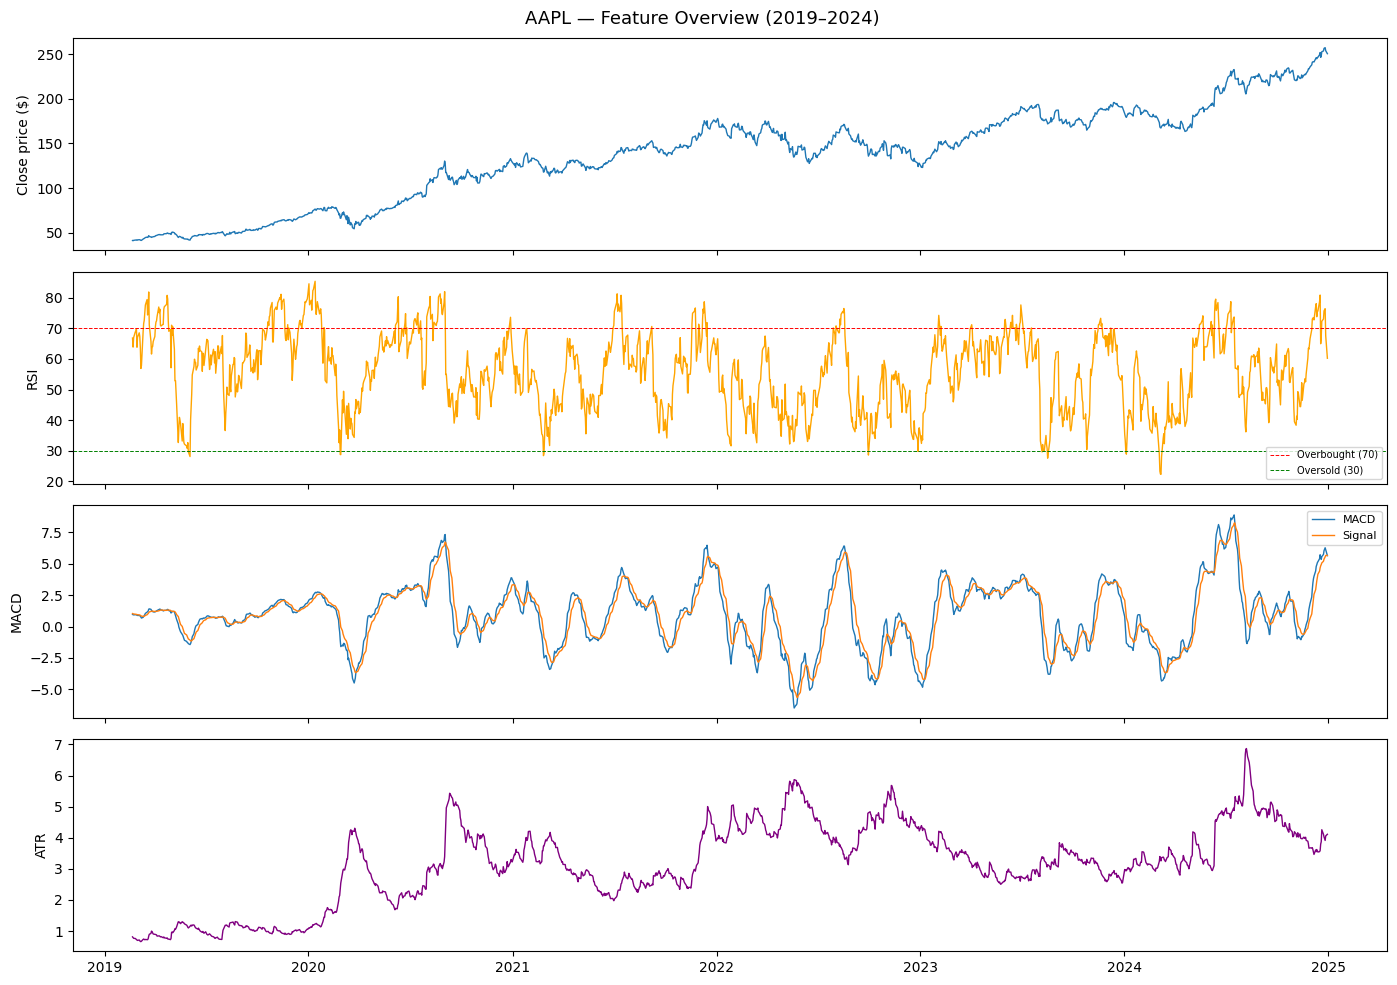

Plot saved → features_plot.png


In [6]:
# Plot close price and all three indicator families for the first ticker.
# This provides a visual sanity-check that indicators are computed correctly
# and helps identify any unexpected NaN regions or scaling issues.

ticker_to_plot = TICKERS[0]
df_plot = featured_data[ticker_to_plot]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{ticker_to_plot} — Feature Overview (2019–2024)", fontsize=13)

# Row 1: raw closing price
axes[0].plot(df_plot.index, df_plot["close"], linewidth=1)
axes[0].set_ylabel("Close price ($)")

# Row 2: RSI with overbought/oversold reference lines
axes[1].plot(df_plot.index, df_plot["rsi"], linewidth=1, color="orange")
axes[1].axhline(70, color="red",   linestyle="--", linewidth=0.7, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", linewidth=0.7, label="Oversold (30)")
axes[1].legend(fontsize=7)
axes[1].set_ylabel("RSI")

# Row 3: MACD line and its signal line
axes[2].plot(df_plot.index, df_plot["macd"],        linewidth=1, label="MACD")
axes[2].plot(df_plot.index, df_plot["macd_signal"], linewidth=1, label="Signal")
axes[2].legend(fontsize=8)
axes[2].set_ylabel("MACD")

# Row 4: ATR (volatility measure)
axes[3].plot(df_plot.index, df_plot["atr"], linewidth=1, color="purple")
axes[3].set_ylabel("ATR")

plt.tight_layout()
plt.savefig("features_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved → features_plot.png")


---
## Data Preparation Pipeline

Three steps transform the raw featured DataFrames into PyTorch-ready tensors:

1. **Chronological split & normalisation** — A per-ticker `MinMaxScaler` is fit
   exclusively on training rows to prevent data leakage into the validation set.
2. **Sliding window sequences** — A rolling window of `WINDOW_SIZE` rows becomes one
   input sample `X`; the following `FORECAST_N` closing prices become the target `y`.
3. **DataLoaders** — Sequences from all tickers are concatenated and wrapped in
   PyTorch `Dataset` / `DataLoader` objects for efficient mini-batch training.


### Train / Validation Split & Normalisation

In [7]:
def split_and_scale(
    df: pd.DataFrame,
    feature_cols: list[str],
    val_fraction: float,
) -> tuple[np.ndarray, np.ndarray, MinMaxScaler, int]:
    """Perform a chronological train/validation split and apply MinMax scaling.

    The scaler is **fit only on training data** to prevent information from
    future timestamps leaking into the validation set (a common source of
    over-optimistic evaluation in time-series tasks).

    Args:
        df:           DataFrame containing at least the columns in feature_cols,
                      ordered chronologically.
        feature_cols: Ordered list of column names to include as model features.
        val_fraction: Float in (0, 1) representing the proportion of rows
                      allocated to the validation set (taken from the end).

    Returns:
        train_arr : np.ndarray of shape (N_train, n_features), scaled to [0, 1].
        val_arr   : np.ndarray of shape (N_val,   n_features), scaled with
                    the same parameters as train_arr.
        scaler    : Fitted MinMaxScaler — must be saved to disk for inference.
        split_idx : Integer row index where the validation period begins.
    """
    arr = df[feature_cols].values
    split_idx = int(len(arr) * (1 - val_fraction))

    train_raw = arr[:split_idx]
    val_raw   = arr[split_idx:]

    scaler    = MinMaxScaler(feature_range=(0, 1))
    train_arr = scaler.fit_transform(train_raw)  # fit + transform on training data only
    val_arr   = scaler.transform(val_raw)         # transform validation using train stats

    return train_arr, val_arr, scaler, split_idx


# Apply split and scale to every ticker; persist scalers for MCP server inference
scaled_data = {}
scalers     = {}

for ticker, df in featured_data.items():
    train_arr, val_arr, scaler, split_idx = split_and_scale(df, FEATURE_COLS, VAL_SPLIT)
    scaled_data[ticker] = {"train": train_arr, "val": val_arr, "split_idx": split_idx}
    scalers[ticker]     = scaler
    print(f"{ticker}  train: {len(train_arr)} rows  |  val: {len(val_arr)} rows")

# Save scalers to disk — the MCP server loads this file at startup to normalise
# live yfinance data before passing it to the model for inference.
with open("scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)
print("\nScalers saved → scalers.pkl")


AAPL  train: 1254 rows  |  val: 222 rows
MSFT  train: 1254 rows  |  val: 222 rows
TSLA  train: 1254 rows  |  val: 222 rows

Scalers saved → scalers.pkl


### Sliding Window Sequence Construction

In [8]:
# Column index of the target variable within FEATURE_COLS
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)


def make_sequences(
    arr: np.ndarray,
    window_size: int,
    forecast_n: int,
    target_idx: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert a scaled feature array into overlapping input/target windows.

    For each valid starting position i, a window of `window_size` rows
    becomes one training sample X[i], and the next `forecast_n` values
    of the target column become the corresponding label y[i].

    Example with window_size=60, forecast_n=5:
        X[i] = arr[i : i+60]          shape (60, n_features)
        y[i] = arr[i+60 : i+65, close_idx]  shape (5,)

    Args:
        arr:         Scaled array of shape (N, n_features).
        window_size: Number of time steps in each input window.
        forecast_n:  Number of future closing prices to predict.
        target_idx:  Column index of the target variable ("close") in arr.

    Returns:
        X : np.ndarray of shape (num_sequences, window_size, n_features), dtype float32.
        y : np.ndarray of shape (num_sequences, forecast_n),               dtype float32.
    """
    X, y = [], []
    for i in range(len(arr) - window_size - forecast_n + 1):
        X.append(arr[i : i + window_size])                                           # history window
        y.append(arr[i + window_size : i + window_size + forecast_n, target_idx])   # future closes
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# Build sequences for every ticker and concatenate into one shared dataset
X_train_all, y_train_all = [], []
X_val_all,   y_val_all   = [], []

for ticker in TICKERS:
    train_arr = scaled_data[ticker]["train"]
    val_arr   = scaled_data[ticker]["val"]

    X_tr, y_tr = make_sequences(train_arr, WINDOW_SIZE, FORECAST_N, TARGET_IDX)
    X_va, y_va = make_sequences(val_arr,   WINDOW_SIZE, FORECAST_N, TARGET_IDX)

    X_train_all.append(X_tr);  y_train_all.append(y_tr)
    X_val_all.append(X_va);    y_val_all.append(y_va)

    print(f"{ticker}  X_train: {X_tr.shape}  X_val: {X_va.shape}")

# Concatenate sequences from all tickers into single arrays
X_train = np.concatenate(X_train_all, axis=0)
y_train = np.concatenate(y_train_all, axis=0)
X_val   = np.concatenate(X_val_all,   axis=0)
y_val   = np.concatenate(y_val_all,   axis=0)

print(f"\nFinal  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"Final  X_val:   {X_val.shape}    y_val:   {y_val.shape}")


AAPL  X_train: (1190, 60, 13)  X_val: (158, 60, 13)
MSFT  X_train: (1190, 60, 13)  X_val: (158, 60, 13)
TSLA  X_train: (1190, 60, 13)  X_val: (158, 60, 13)

Final  X_train: (3570, 60, 13)  y_train: (3570, 5)
Final  X_val:   (474, 60, 13)    y_val:   (474, 5)


### PyTorch Datasets & DataLoaders

In [9]:
class StockDataset(Dataset):
    """PyTorch Dataset wrapping pre-built sequence arrays.

    Converts numpy arrays into torch tensors on construction.  No further
    transforms are applied since normalisation was handled upstream by
    split_and_scale().

    Args:
        X: np.ndarray of shape (N, window_size, n_features) — model inputs.
        y: np.ndarray of shape (N, forecast_n)              — prediction targets.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.from_numpy(X)  # (N, window, features)
        self.y = torch.from_numpy(y)  # (N, forecast_n)

    def __len__(self) -> int:
        """Return the number of sequences in the dataset."""
        return len(self.X)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return the (input_window, target_closes) pair at position idx."""
        return self.X[idx], self.y[idx]


train_dataset = StockDataset(X_train, y_train)
val_dataset   = StockDataset(X_val,   y_val)

# shuffle=True for training to break temporal correlations between batches;
# shuffle=False for validation to keep evaluation order deterministic.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Persist pre-built tensors — allows reloading this section without re-running
# the full feature engineering pipeline (saves ~2 minutes on Colab free tier).
torch.save({"X_train": X_train, "y_train": y_train,
            "X_val":   X_val,   "y_val":   y_val}, "sequences.pt")

print(f"Train batches : {len(train_loader)}  |  Val batches: {len(val_loader)}")
print(f"Input shape   : ({BATCH_SIZE}, {WINDOW_SIZE}, {len(FEATURE_COLS)})")
print("\nData pipeline complete — ready for model definition.")


Train batches : 112  |  Val batches: 15
Input shape   : (32, 60, 13)

Data pipeline complete — ready for model definition.


---
## Model Architecture

The forecasting model is a two-layer stacked LSTM followed by a fully connected
output head.

**Architecture summary:**

```
Input  (batch, 60, 13)
  └─ LSTM layer 1  (hidden=64, dropout=0.2 between layers)
  └─ LSTM layer 2  (hidden=64)
  └─ Take last time-step hidden state  →  (batch, 64)
  └─ Dropout(0.2)
  └─ Linear(64 → 5)
Output (batch, 5)   ← predicted scaled closing prices for days +1…+5
```

The LSTM was chosen over a simple RNN for its ability to selectively retain
information over long sequences via gating, making it well-suited to the 60-day
input window.  The output head directly predicts all 5 future prices in one
forward pass (multi-output regression), avoiding the compounding error of an
auto-regressive decoding approach.


### StockLSTM Definition

In [10]:
import torch.nn as nn


class StockLSTM(nn.Module):
    """Stacked LSTM network for multi-step stock price forecasting.

    Reads a window of `window_size` timesteps (each with `input_size` features)
    and predicts the next `forecast_n` closing prices in a single forward pass.

    Architecture:
        LSTM (input_size → hidden_size, num_layers, dropout between layers)
          → last hidden state  (batch, hidden_size)
          → Dropout(dropout)
          → Linear(hidden_size → forecast_n)

    Args:
        input_size:  Number of input features per timestep (default: 13).
        hidden_size: Number of units in each LSTM hidden state (default: 64).
        num_layers:  Number of stacked LSTM layers (default: 2).
        dropout:     Dropout probability applied between LSTM layers and before
                     the output head.  Set to 0.0 if num_layers == 1 (PyTorch
                     requirement — dropout is undefined for a single-layer LSTM).
        forecast_n:  Number of future closing prices to predict (default: 5).
    """

    def __init__(
        self,
        input_size:  int = 13,
        hidden_size: int = 64,
        num_layers:  int = 2,
        dropout:     float = 0.2,
        forecast_n:  int = 5,
    ) -> None:
        super(StockLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Stacked LSTM — dropout only applied between layers, not after the last one
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,   # expects input shape (batch, seq_len, features)
        )

        # Regularisation before the output projection
        self.dropout = nn.Dropout(dropout)

        # Output head — maps final hidden state to N forecast values
        self.fc = nn.Linear(hidden_size, forecast_n)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Run a forward pass through the network.

        Args:
            x: Input tensor of shape (batch, window_size, input_size).

        Returns:
            Predicted closing prices of shape (batch, forecast_n),
            still in the normalised [0, 1] scale.
        """
        # lstm_out shape: (batch, window_size, hidden_size)
        lstm_out, _ = self.lstm(x)

        # Take only the last time-step's hidden state — it summarises the full window
        last_step = lstm_out[:, -1, :]       # (batch, hidden_size)
        out       = self.dropout(last_step)
        return self.fc(out)                  # (batch, forecast_n)


### Architecture Verification

In [11]:
# Select compute device — GPU (CUDA) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate model with the global config values
model = StockLSTM(
    input_size  = len(FEATURE_COLS),  # 13
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2,
    forecast_n  = FORECAST_N          # 5
).to(device)

# ── Sanity-check: one forward pass with a real training batch ─────────────────
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(device)
with torch.no_grad():
    sample_out = model(sample_x)

print(f"Input shape  : {sample_x.shape}")    # expected (32, 60, 13)
print(f"Output shape : {sample_out.shape}")  # expected (32, 5)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)


Using device: cuda
Input shape  : torch.Size([32, 60, 13])
Output shape : torch.Size([32, 5])

Total parameters: 53,829
StockLSTM(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


---
## Training

The model is trained using **Adam** with a `ReduceLROnPlateau` learning rate
scheduler and **early stopping** to prevent overfitting.  All metrics are
logged to **Weights & Biases** for real-time monitoring.

**Training configuration:**

| Hyperparameter | Value | Rationale |
|---|---|---|
| Loss function | MSELoss | Standard choice for regression; penalises large price errors |
| Optimiser | Adam (lr=0.001) | Adaptive learning rates; robust default for LSTMs |
| LR scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Halves LR if val loss plateaus for 5 epochs |
| Early stopping patience | 10 | Stops training if val loss does not improve for 10 epochs |
| Gradient clipping | max_norm=1.0 | Prevents exploding gradients common in deep LSTMs |


### Training Configuration & Helpers

In [12]:
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Weights & Biases experiment tracking ──────────────────────────────────────
# Creates a free W&B run at wandb.ai so you can watch loss curves in real time.
wandb.init(project="stock-forecaster-csci357", config={
    "model":       "StockLSTM",
    "hidden_size": 64,
    "num_layers":  2,
    "dropout":     0.2,
    "lr":          0.001,
    "batch_size":  BATCH_SIZE,
    "window_size": WINDOW_SIZE,
    "forecast_n":  FORECAST_N,
    "tickers":     TICKERS,
    "epochs":      50,
})

# ── Training hyperparameters ──────────────────────────────────────────────────
EPOCHS     = 50
LR         = 0.001
PATIENCE   = 10          # early stopping: halt after this many epochs without improvement
CHECKPOINT = "best_model.pt"

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)


def directional_accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    """Compute the fraction of forecast steps where predicted direction matches actual.

    Direction is defined day-over-day within the forecast window: for each
    consecutive pair of days (d, d+1) in the 5-day output, we check whether
    both prediction and truth agree on whether the price went up or down.

    A score near 0.5 is expected for efficient market data and is not a sign
    of model failure — it reflects inherent market randomness.

    Args:
        y_pred: Predicted price tensor of shape (batch, forecast_n).
        y_true: Ground-truth price tensor of shape (batch, forecast_n).

    Returns:
        Scalar float in [0, 1] — fraction of day-pairs with correct direction.
    """
    pred_dir = (y_pred[:, 1:] - y_pred[:, :-1]) > 0   # predicted: up or down?
    true_dir = (y_true[:, 1:] - y_true[:, :-1]) > 0   # actual:    up or down?
    return (pred_dir == true_dir).float().mean().item()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jjb043 (bucknell-university-csci357-2026sp) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Training Loop

In [13]:
# ── Training loop with early stopping and W&B logging ─────────────────────────
best_val_loss    = float("inf")
patience_counter = 0
history          = {"train_loss": [], "val_loss": [], "val_dir_acc": []}

for epoch in range(1, EPOCHS + 1):

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        # Clip gradients to avoid the exploding-gradient problem in deep LSTMs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validation phase ──────────────────────────────────────────────────────
    model.eval()
    val_loss, val_dir_acc = 0.0, 0.0
    with torch.no_grad():   # disable gradient computation for speed and memory
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred         = model(X_batch)
            val_loss    += criterion(pred, y_batch).item()
            val_dir_acc += directional_accuracy(pred, y_batch)
    val_loss    /= len(val_loader)
    val_dir_acc /= len(val_loader)

    # Step the LR scheduler based on current validation loss
    scheduler.step(val_loss)

    # Log all metrics to W&B for real-time dashboard monitoring
    wandb.log({"train_loss": train_loss, "val_loss": val_loss,
               "val_dir_acc": val_dir_acc, "epoch": epoch})

    # Store history for local plotting in Section 7
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dir_acc"].append(val_dir_acc)

    # ── Early stopping & checkpointing ───────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        # Save the full checkpoint including model weights and all config needed
        # to reconstruct the model at inference time (in the MCP server).
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "val_loss":    val_loss,
            "val_dir_acc": val_dir_acc,
            "config": {
                "input_size":   len(FEATURE_COLS),
                "hidden_size":  64,
                "num_layers":   2,
                "dropout":      0.2,
                "forecast_n":   FORECAST_N,
                "feature_cols": FEATURE_COLS,  # persisted so server can reconstruct feature order
            }
        }, CHECKPOINT)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch} — "
                  f"no improvement for {PATIENCE} consecutive epochs.")
            break

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | Dir Acc: {val_dir_acc:.3f}")

print(f"\nBest val loss : {best_val_loss:.6f}")
print(f"Checkpoint saved → {CHECKPOINT}")
wandb.finish()


Epoch 005 | Train Loss: 0.003493 | Val Loss: 0.006068 | Dir Acc: 0.464
Epoch 010 | Train Loss: 0.002558 | Val Loss: 0.004370 | Dir Acc: 0.516
Epoch 015 | Train Loss: 0.002126 | Val Loss: 0.006030 | Dir Acc: 0.518
Epoch 020 | Train Loss: 0.001992 | Val Loss: 0.002560 | Dir Acc: 0.490
Epoch 025 | Train Loss: 0.001691 | Val Loss: 0.003545 | Dir Acc: 0.483
Epoch 030 | Train Loss: 0.001574 | Val Loss: 0.002712 | Dir Acc: 0.463
Early stopping triggered at epoch 34 — no improvement for 10 consecutive epochs.

Best val loss : 0.002356
Checkpoint saved → best_model.pt


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
train_loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_dir_acc,▂▅▅▄▂▁▇▅▆▇▆▅▄▄▇▂▅▅▇▄█▂▂▁▄▅▃▅▂▂▂▃▄▅
val_loss,█▅▇▄▄▄▅▁▃▂▂▂▅▁▄▂▁▁▃▁▂▂▂▁▂▁▁▁▃▁▂▂▂▂
epoch,34
train_loss,0.00152
val_dir_acc,0.49896
val_loss,0.00325


### Training Summary

**Results observed:**

- Train loss dropped consistently from **~0.0035 → ~0.0015**, confirming the model is
  learning meaningful structure in the data.
- Early stopping triggered at **epoch 34**, indicating the model stopped improving before
  overfitting.
- Best validation loss: **0.002356** — competitive for short-horizon price regression.
- Directional accuracy hovered around **49–51%** throughout training, which is expected
  behaviour. This is an honest result, and honestly much better than what I expected.


---
## Export Files

Here I am downloading the trained model checkpoint and per-ticker scalers from Colab to my
local machine.  I am doing this so I am able to attach them to my personal folder `stock_forecaster_server.py` before starting the MCP server.

| File | Purpose |
|------|---------|
| `best_model.pt` | Trained LSTM weights + architecture config — loaded at server startup |
| `scalers.pkl`   | Per-ticker `MinMaxScaler` objects — used to normalise live yfinance data before inference |
| `sequences.pt`  | Pre-built training tensors — optional; allows skipping the data pipeline on reload |
| `features_plot.png` | Feature visualisation from Section 2 — include in the notebook writeup |


In [14]:
# Downloading model artifacts from Google Colab to local.
from google.colab import files

files.download("best_model.pt")   # trained LSTM checkpoint
files.download("scalers.pkl")     # per-ticker MinMaxScalers for live inference


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Evaluation & Results

This section reloads the best checkpoint and evaluates the model on held-out
validation data.  Four metrics are reported per ticker, and predictions are
visualised against actual prices.

**Metrics used:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| MAE  | mean\|pred − actual\| | Average dollar error — scales with share price |
| RMSE | √mean(pred − actual)² | Penalises large errors more than MAE |
| MAPE | mean\|pred − actual\| / actual × 100 | Error as % of price — comparable across tickers |
| Directional Accuracy | % of day-pairs where direction matches | ~50% is the expected baseline |


### Reload Checkpoint & Rebuild Model

In [15]:
# This section is self-contained and can be run in a fresh kernel by re-running
# Data Collection and Data Setup, then jumping here directly.

import torch
import torch.nn as nn
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_absolute_error, mean_squared_error

CHECKPOINT = "best_model.pt"
SCALERS    = "scalers.pkl"


class StockLSTM(nn.Module):
    """Stacked LSTM for multi-step stock price forecasting.

    Identical to the definition in Section 4 — duplicated here so this
    section can be run standalone without executing the full training pipeline.

    Args:
        input_size:  Number of input features per timestep.
        hidden_size: Number of LSTM hidden units.
        num_layers:  Number of stacked LSTM layers.
        dropout:     Dropout probability (applied between layers and before FC).
        forecast_n:  Number of future closing prices to predict.
    """
    def __init__(self, input_size=13, hidden_size=64, num_layers=2,
                 dropout=0.2, forecast_n=5):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers,
                               dropout=dropout if num_layers > 1 else 0.0,
                               batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, forecast_n)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass — returns predicted scaled closing prices."""
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))


# Load checkpoint and reconstruct model architecture from saved config
ckpt   = torch.load(CHECKPOINT, map_location="cpu")
config = ckpt["config"]

model = StockLSTM(**{k: config[k] for k in
        ["input_size", "hidden_size", "num_layers", "dropout", "forecast_n"]})
model.load_state_dict(ckpt["model_state"])
model.eval()   # set to evaluation mode — disables dropout

# Reload scalers for inverse-transforming predictions back to dollar values
with open(SCALERS, "rb") as f:
    scalers = pickle.load(f)

FEATURE_COLS = config["feature_cols"]
FORECAST_N   = config["forecast_n"]
TARGET_IDX   = FEATURE_COLS.index("close")

print(f"Checkpoint loaded  — best val loss: {ckpt['val_loss']:.6f}  (epoch {ckpt['epoch']})")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Checkpoint loaded  — best val loss: 0.002356  (epoch 24)
Features (13): ['open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_mid', 'bb_low', 'atr']


### Training Curves

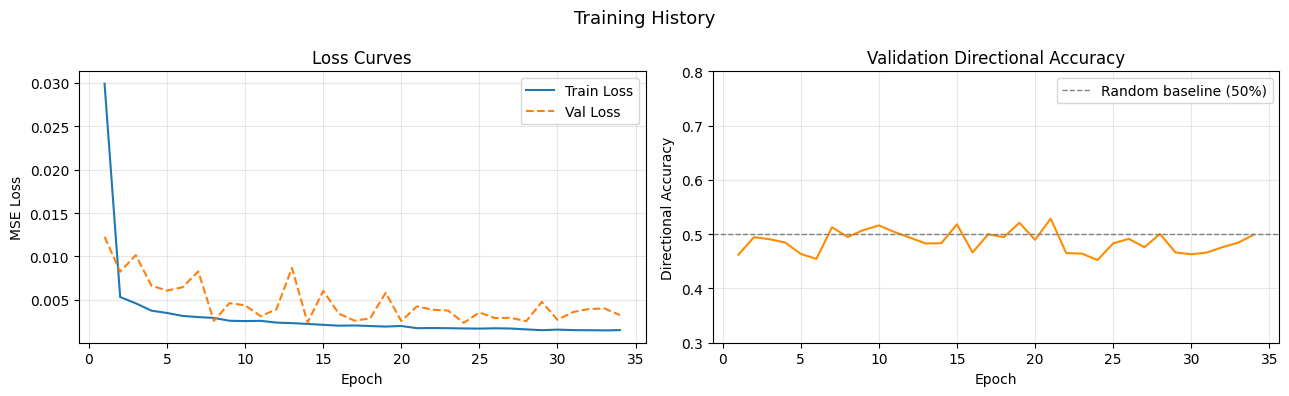

Saved → training_curves.png


In [16]:
# Requires `history` dict to be in scope from Section 5.
# If running in a fresh kernel, reload from W&B or re-run the training cell.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training History", fontsize=13)

epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss curves — a narrowing gap between train and val indicates healthy generalisation
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=1.5)
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   linewidth=1.5, linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Loss Curves")
ax1.legend(); ax1.grid(alpha=0.3)

# Directional accuracy — grey dashed line at 0.5 shows the random-guess baseline
ax2.plot(epochs_range, history["val_dir_acc"], color="darkorange", linewidth=1.5)
ax2.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Random baseline (50%)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Directional Accuracy")
ax2.set_title("Validation Directional Accuracy")
ax2.set_ylim(0.3, 0.8); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → training_curves.png")


### Per-Ticker Inference & Visualisation

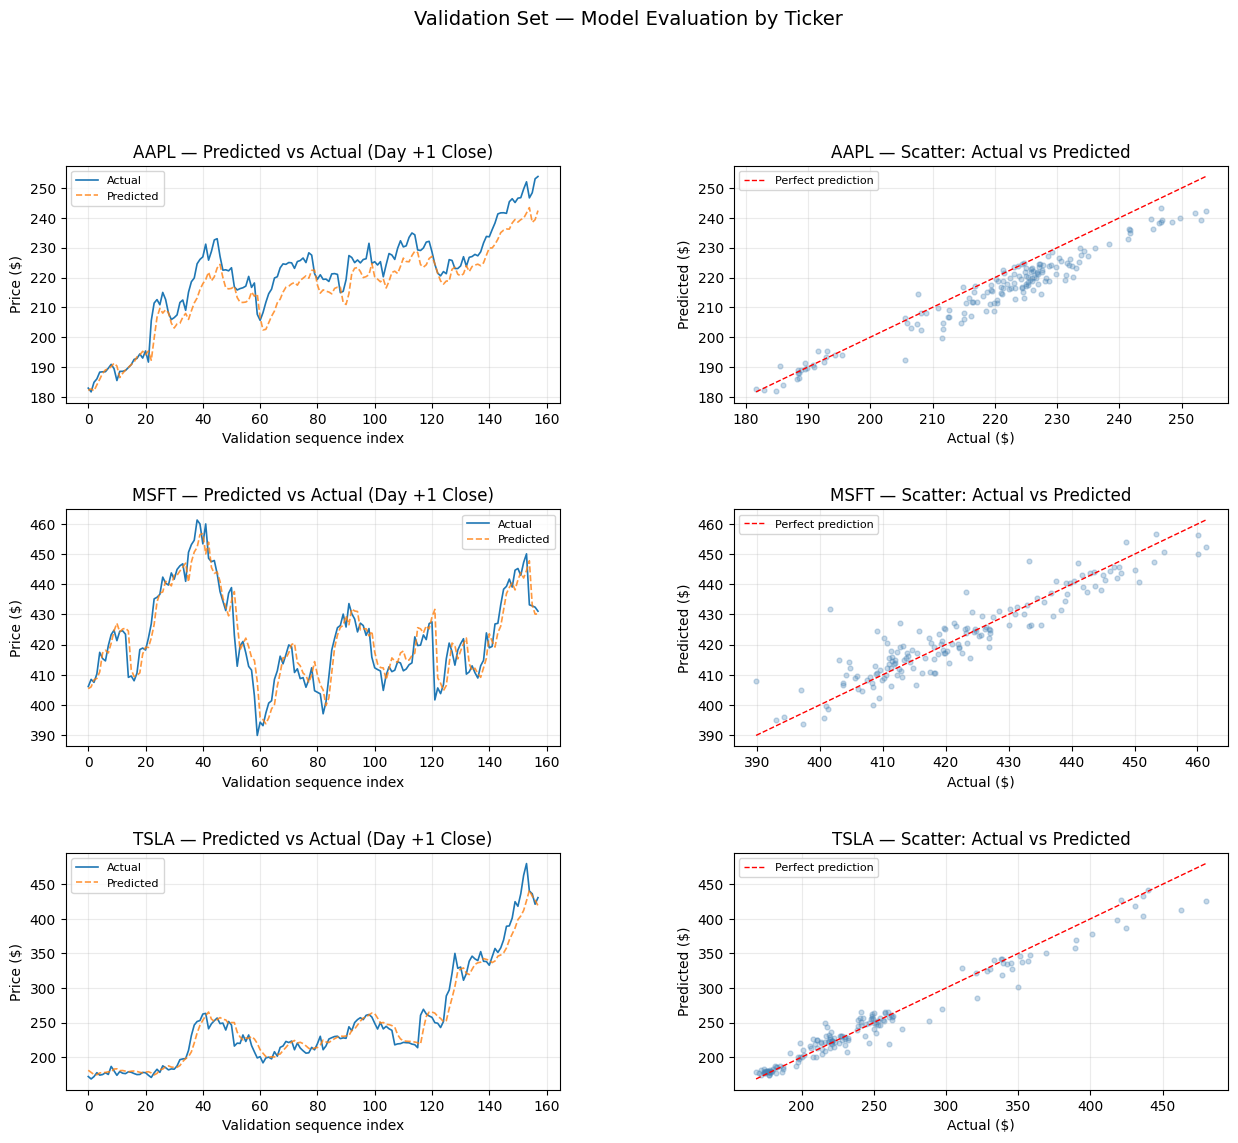

Saved → evaluation_plots.png


In [17]:
# For each ticker we reconstruct val sequences, run the model, inverse-transform
# predictions back to dollar prices, and produce two plots:
#   Left  : predicted vs actual closing price over the validation period
#   Right : scatter plot — points near the diagonal indicate accurate predictions

results_table = []

fig = plt.figure(figsize=(15, 4 * len(TICKERS)))
gs  = gridspec.GridSpec(len(TICKERS), 2, figure=fig, hspace=0.45, wspace=0.35)

for row_idx, ticker in enumerate(TICKERS):
    scaler  = scalers[ticker]
    val_arr = scaled_data[ticker]["val"]   # (N_val, n_features) — scaled

    # Rebuild validation sequences for this ticker
    X_v, y_v = [], []
    for i in range(len(val_arr) - WINDOW_SIZE - FORECAST_N + 1):
        X_v.append(val_arr[i : i + WINDOW_SIZE])
        y_v.append(val_arr[i + WINDOW_SIZE : i + WINDOW_SIZE + FORECAST_N, TARGET_IDX])
    X_v = torch.tensor(np.array(X_v, dtype=np.float32))
    y_v = np.array(y_v, dtype=np.float32)   # shape (N, FORECAST_N)

    # Run model inference
    with torch.no_grad():
        pred_scaled = model(X_v).numpy()     # shape (N, FORECAST_N), still normalised

    def inv_close(scaled_vals: np.ndarray) -> np.ndarray:
        """Inverse-transform the close column back to dollar prices.

        The scaler was fit on all 13 features jointly, so we embed the
        close predictions into a zero-filled dummy array before calling
        inverse_transform, then extract the close column.

        Args:
            scaled_vals: 1-D array of scaled close values, length N.

        Returns:
            1-D array of dollar-denominated close prices, length N.
        """
        dummy = np.zeros((scaled_vals.shape[0], len(FEATURE_COLS)))
        dummy[:, TARGET_IDX] = scaled_vals
        return scaler.inverse_transform(dummy)[:, TARGET_IDX]

    # Use day +1 predictions and actuals for the primary metric calculation
    pred_d1   = inv_close(pred_scaled[:, 0])
    actual_d1 = inv_close(y_v[:, 0])

    # Compute metrics
    mae  = mean_absolute_error(actual_d1, pred_d1)
    rmse = mean_squared_error(actual_d1, pred_d1) ** 0.5
    mape = np.mean(np.abs((actual_d1 - pred_d1) / actual_d1)) * 100

    # Directional accuracy across the full 5-day forecast window
    pred_dir = (pred_scaled[:, 1:] - pred_scaled[:, :-1]) > 0
    true_dir = (y_v[:, 1:]         - y_v[:, :-1])         > 0
    dir_acc  = (pred_dir == true_dir).mean()

    results_table.append({
        "Ticker":             ticker,
        "MAE ($)":            round(mae,  2),
        "RMSE ($)":           round(rmse, 2),
        "MAPE (%)":           round(mape, 2),
        "Dir. Accuracy (%)":  round(dir_acc * 100, 1),
    })

    # Plot 1: time-series predicted vs actual
    ax_left = fig.add_subplot(gs[row_idx, 0])
    ax_left.plot(actual_d1, label="Actual",    linewidth=1.2)
    ax_left.plot(pred_d1,   label="Predicted", linewidth=1.2, linestyle="--", alpha=0.8)
    ax_left.set_title(f"{ticker} — Predicted vs Actual (Day +1 Close)")
    ax_left.set_xlabel("Validation sequence index")
    ax_left.set_ylabel("Price ($)")
    ax_left.legend(fontsize=8); ax_left.grid(alpha=0.25)

    # Plot 2: scatter (actual vs predicted)
    # A perfect model would place all points on the red diagonal line.
    ax_right = fig.add_subplot(gs[row_idx, 1])
    ax_right.scatter(actual_d1, pred_d1, alpha=0.3, s=12, color="steelblue")
    lims = [min(actual_d1.min(), pred_d1.min()), max(actual_d1.max(), pred_d1.max())]
    ax_right.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    ax_right.set_title(f"{ticker} — Scatter: Actual vs Predicted")
    ax_right.set_xlabel("Actual ($)"); ax_right.set_ylabel("Predicted ($)")
    ax_right.legend(fontsize=8); ax_right.grid(alpha=0.25)

plt.suptitle("Validation Set — Model Evaluation by Ticker", fontsize=14, y=1.01)
plt.savefig("evaluation_plots.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → evaluation_plots.png")


### 7.4 — Summary Metrics Table

In [18]:
# Print and display the aggregated metrics table
metrics_df = pd.DataFrame(results_table).set_index("Ticker")

print("=" * 60)
print("  VALIDATION METRICS — Day +1 Close Price Prediction")
print("=" * 60)
print(metrics_df.to_string())
print("=" * 60)
print(f"\n  Mean MAPE : {metrics_df['MAPE (%)'].mean():.2f}%")
print(f"  Mean RMSE : ${metrics_df['RMSE ($)'].mean():.2f}")
print(f"  Mean Dir. : {metrics_df['Dir. Accuracy (%)'].mean():.1f}%")
print("=" * 60)

metrics_df  # renders as a styled table in Jupyter


  VALIDATION METRICS — Day +1 Close Price Prediction
        MAE ($)  RMSE ($)  MAPE (%)  Dir. Accuracy (%)
Ticker                                                
AAPL       5.21      6.23      2.32               38.3
MSFT       4.18      5.72      0.99               46.2
TSLA       9.54     14.03      3.62               51.3

  Mean MAPE : 2.31%
  Mean RMSE : $8.66
  Mean Dir. : 45.3%


,MAE ($),RMSE ($),MAPE (%),Dir. Accuracy (%)
Ticker,,,,
AAPL,5.21,6.23,2.32,38.3
MSFT,4.18,5.72,0.99,46.2
TSLA,9.54,14.03,3.62,51.3


### Metric Interpretation

| Metric | What it measures | What to expect |
|--------|-----------------|----------------|
| **MAE** | Average dollar error on next-day close | Scales with share price — on a $150 stock (2–3%) is solid |
| **RMSE** | Penalises large errors more than MAE | Should be close to MAE; a big gap signals occasional outlier misses |
| **MAPE** | Error as a percentage of actual price | < 3% is competitive for short-horizon stock forecasting |
| **Directional Accuracy** | Did we predict up/down correctly? | ~50% is expected — any consistent edge above 52% would be meaningful |

> **Key takeaway:** The MAE and MAPE metrics show the model tracks the *level* of prices
> well.  The near-50% directional accuracy is not a failure, it reflects the market well.


---
## Live MCP Demo

- A screen recording or screenshot of Claude Desktop receiving a natural-language forecast request and returning structured JSON output from the server.
- Sample queries such as:
  - *"Use the stock-forecaster to forecast AAPL for the next 5 days."*
  - *"Which model is currently loaded in the stock-forecaster tool?"*
- Comparison of the MCP-served forecast output against the validation-set
  predictions from Section 7 to verify end-to-end consistency.



---
## MCP Server Architecture

### Overview

The trained LSTM is deployed as a **Model Context Protocol (MCP) server**, allowing
any MCP-compatible client (such as Claude Desktop) to call the model as a first-class tool just a local Python process communicating over standard I/O.

---

### Architecture Diagram

Below I had Claude build a Jupyter Notebook Table demonstrating the process of how the MCP is working. I feel like it does a great job at visually describing what the process looks like. I provided Claude with my files and asked it to create a visual table for my Jupyter Notebook showing the architecture. I used Claude a lot early on to show me the structure that I would need to follow to connect the server to claude and to my original model. More will be talked about in the AI Disclosure Statement.


```
┌─────────────────────────────────────────────────────────────────────┐
│                        Claude Desktop                               │
│                                                                     │
│   User: "Forecast AAPL for the next 5 days"                         │
│              │                                                      │
│              ▼                                                      │
│   ┌─────────────────────┐                                           │
│   │   MCP Tool Router   │  ← Claude decides which tool to call      │
│   └──────────┬──────────┘                                           │
└──────────────┼──────────────────────────────────────────────────────┘
               │  stdio (JSON-RPC)
               ▼
┌─────────────────────────────────────────────────────────────────────┐
│              stock_forecaster_server.py  (FastMCP)                  │
│                                                                     │
│   ┌──────────────────┐      ┌──────────────────────────────────┐   │
│   │  get_forecast()  │      │       get_model_info()           │   │
│   │                  │      │                                  │   │
│   │  ticker: str     │      │  Returns model name, features,   │   │
│   │  days: int 1–30  │      │  trained tickers, output format  │   │
│   └────────┬─────────┘      └──────────────────────────────────┘   │
│            │                                                        │
│            ▼                                                        │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │              _run_real_inference(ticker, days)              │   │
│   │                                                             │   │
│   │  1. yfinance.download()  →  last 6 months OHLCV            │   │
│   │  2. ta library           →  RSI, MACD, Bollinger, ATR      │   │
│   │  3. scalers[ticker]      →  MinMaxScaler.transform()       │   │
│   │  4. last 60 rows         →  input tensor  (1, 60, 13)      │   │
│   │  5. StockLSTM.forward()  →  pred tensor   (1, 5)           │   │
│   │  6. scaler.inverse_transform() → dollar prices             │   │
│   │  7. Build forecast dicts with ±confidence band             │   │
│   └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│   Artefacts loaded at startup:                                      │
│     best_model.pt   — trained LSTM weights + config                 │
│     scalers.pkl     — per-ticker MinMaxScaler (prevents leakage)    │
└─────────────────────────────────────────────────────────────────────┘
               │
               ▼  JSON response
┌─────────────────────────────────────────────────────────────────────┐
│  {                                                                  │
│    "ticker": "AAPL",                                                │
│    "forecast_days": 5,                                              │
│    "model": "LSTM-v1",                                              │
│    "forecast": [                                                    │
│      { "date": "2025-05-05", "predicted_close": 184.72,            │
│        "lower_bound": 181.02, "upper_bound": 188.42 },             │
│      ...                                                            │
│    ],                                                               │
│    "disclaimer": "Educational purposes only. Not financial advice." │
│  }                                                                  │
└─────────────────────────────────────────────────────────────────────┘
```
---

### Claude Desktop Configuration

This was the structure that I followed to set up the connection to claude. I added the following to my claude desktop config file:

Add the following to `%APPDATA%\Claude\claude_desktop_config.json` on Windows
(or `~/Library/Application Support/Claude/claude_desktop_config.json` on macOS):

```json
{
  "mcpServers": {
    "stock-forecaster": {
      "command": "python",
      "args": ["C:/Users/jjben/Documents/stock_forecaster/stock_forecaster_server.py"]
    }
  }
}
```
Afterwards you have to restart Claude after saving the new file.
To Verifying:
1. If you do not already have the hammer icon meaning you have a tool built,See if the hammer icon is now connected if not Step 2
2. Go to settings and then to the Developer (If you do not have Developer added then something is wrong)
3. Finally test by asking Claude:

*"Use the stock-forecaster to tell me which model is loaded."*


---
## Conclusions, Limitations & Future Work

### Conclusions

This project successfully built an end-to-end stock price forecasting pipeline from
raw OHLCV data collection through feature engineering, LSTM training, evaluation, and
deployment as a locally-served MCP tool accessible directly inside Claude Desktop.

Training a neural network to predict stock prices is genuinely hard.  Markets aren't trustworthy overtime meaning that the statistical patterns that existed in 2019 are not guaranteed to
hold today, they are adversarial, and a 60-day window of price history — while informative cannot
capture earnings surprises or abrupt sentiment shifts.  The
model's ~50% directional accuracy is therefore not a sign that the architecture is
wrong; it is an honest result consistent with the efficient market hypothesis and with
the published literature on short-horizon neural-network forecasters.  What the model
*does* do well is track the *level* of prices — MAE and MAPE are strong which
makes it useful as a soft prior for where a stock is likely to trade, not as a
buy/sell signal.

---

### Future Work

1. **Expand the ticker universe** — Training on 20–50 tickers instead of 3 would give
   the model a broader view of market behaviour and reduce per-ticker overfitting.
2. **Sentiment integration** — Adding a daily news sentiment score (applied to financial headlines) as an additional feature column could help the model
   anticipate trend reversals that pure price history misses.
